First 5 Rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

/tmp/ipykernel_793/2334919016.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna("Unknown", inplace=True)
/tmp/ipykernel_793/2334919016.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

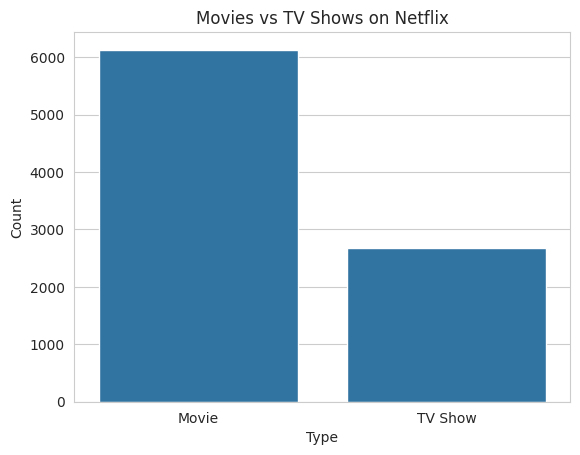

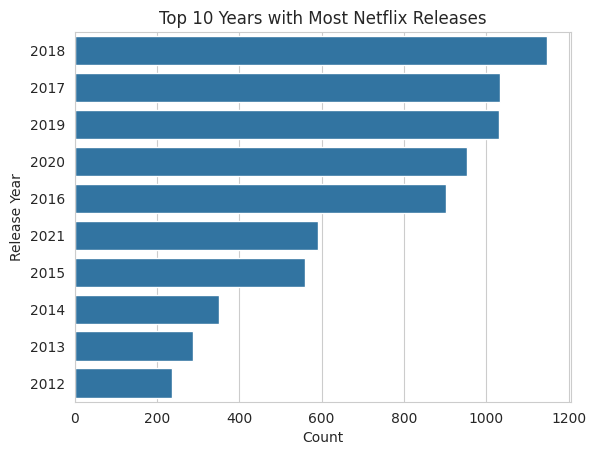

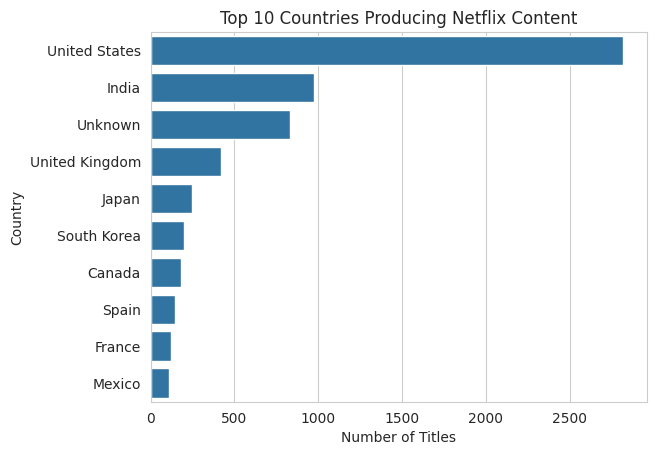

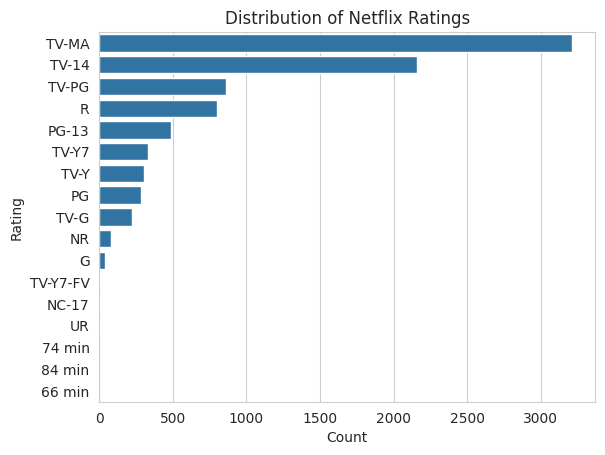

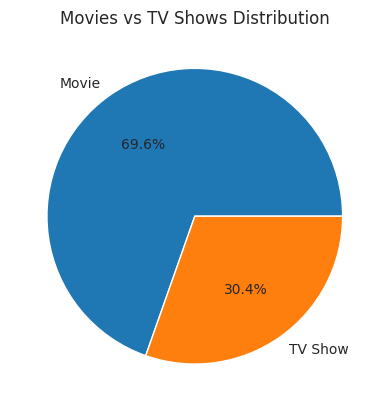

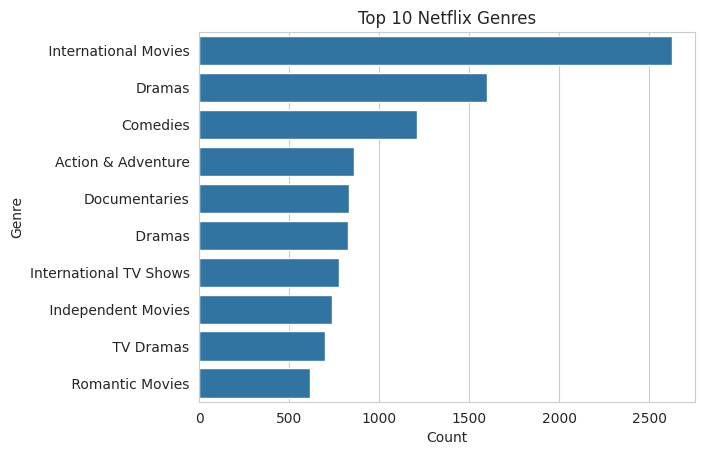

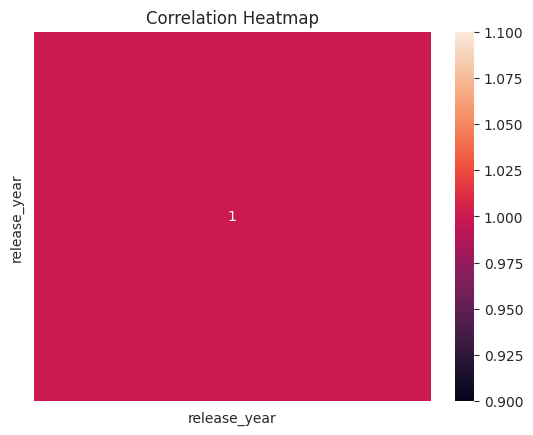


Key Insights:
1. Netflix has more Movies than TV Shows.
2. Content production increased significantly in recent years.
3. United States produces the most Netflix content.
4. TV-MA is one of the most common ratings.
5. International Movies and Dramas are among the most common genres.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#Load Dataset
df = pd.read_csv("netflix.csv")

#Display First Rows
print("First 5 Rows:")
print(df.head())

#Dataset Information
print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

#Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

#Handle Missing Values
df['director'].fillna("Unknown", inplace=True)
df['cast'].fillna("Unknown", inplace=True)
df['country'].fillna("Unknown", inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['duration'].fillna(df['duration'].mode()[0], inplace=True)

#Check Missing Values Again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

#Movies vs TV Shows Count Plot
plt.figure()
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

#Top 10 Release Years
plt.figure()
sns.countplot(y='release_year', data=df, order=df['release_year'].value_counts().index[:10])
plt.title("Top 10 Years with Most Netflix Releases")
plt.xlabel("Count")
plt.ylabel("Release Year")
plt.show()

#Top 10 Countries Producing Netflix Content
top_countries = df['country'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

#Ratings Distribution
plt.figure()
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Distribution of Netflix Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

#Movies vs TV Shows Pie Chart
type_counts = df['type'].value_counts()

plt.figure()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%')
plt.title("Movies vs TV Shows Distribution")
plt.show()

#Most Common Genres
genres = df['listed_in'].str.split(',', expand=True).stack()

top_genres = genres.value_counts().head(10)

plt.figure()
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Netflix Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

#Correlation Heatmap (Numeric Columns)
numeric_df = df.select_dtypes(include=np.number)

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

print("\nKey Insights:")
print("1. Netflix has more Movies than TV Shows.")
print("2. Content production increased significantly in recent years.")
print("3. United States produces the most Netflix content.")
print("4. TV-MA is one of the most common ratings.")
print("5. International Movies and Dramas are among the most common genres.")